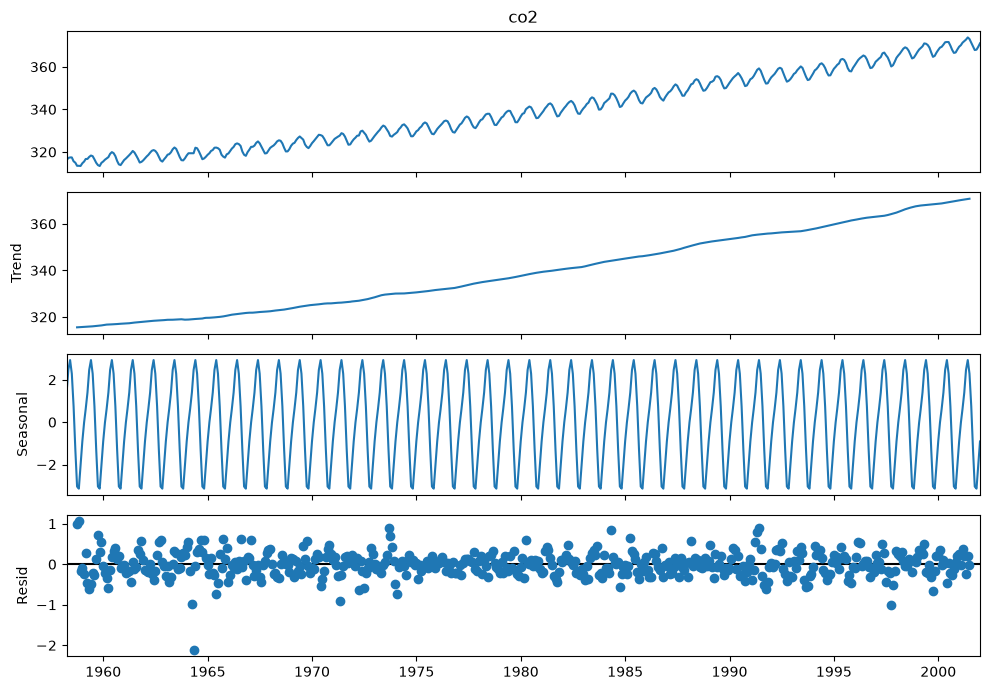

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

co2 = sm.datasets.co2.load_pandas().data
co2 = co2["co2"].resample("ME").mean().ffill()

decomposition = seasonal_decompose(co2, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

## Step 2 — Model Choice

The decomposition confirms both a clear long-term trend and strong, regular 
yearly seasonality (12-month period). This rules out simple models like plain 
ARIMA (no seasonal handling) or basic linear regression (can't capture the 
repeating seasonal cycle). SARIMA is chosen because its seasonal component 
(P,D,Q,s) explicitly models the 12-month cycle seen in the decomposition, 
while its non-seasonal component (p,d,q) handles the trend.

In [2]:
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

In [3]:
from sklearn.metrics import mean_absolute_error

def rolling_backtest(series, order, seasonal_order, n_splits=5, test_size=12):
    results = []
    total_len = len(series)
    for i in range(n_splits):
        split_point = total_len - test_size * (n_splits - i)
        train = series[:split_point]
        test = series[split_point:split_point + test_size]
        
        if len(test) < test_size:
            continue

        model = sm.tsa.statespace.SARIMAX(train, order=order, seasonal_order=seasonal_order,
                                           enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        forecast = fitted.get_forecast(steps=test_size).predicted_mean
        
        naive = pd.Series(train[-12:].values, index=test.index[:12])
        
        sarima_mae = mean_absolute_error(test, forecast)
        naive_mae = mean_absolute_error(test, naive[:len(test)])
        
        results.append({"window": i+1, "train_end": train.index[-1], "sarima_mae": sarima_mae, "naive_mae": naive_mae})
    return pd.DataFrame(results)

backtest_results = rolling_backtest(co2, order, seasonal_order)
backtest_results

,window,train_end,sarima_mae,naive_mae
0,1,1996-12-31,0.421309,1.108750
1,2,1997-12-31,1.068382,2.913750
2,3,1998-12-31,0.503816,1.610833
3,4,1999-12-31,0.287210,1.135833
4,5,2000-12-31,0.268387,1.492917


## Step 4 — Tuning Decision

SARIMA(1,1,1)(1,1,1,12) beat the naive baseline in all 5 of 5 backtest 
windows, with MAE improvements ranging from 2.6x to 5.6x better than naive. 
Given this consistent, strong performance across every window (not just one), 
no further tuning was pursued — additional parameter search would likely 
yield marginal gains at the cost of overfitting to this specific dataset. 
The current order was retained as the final model.

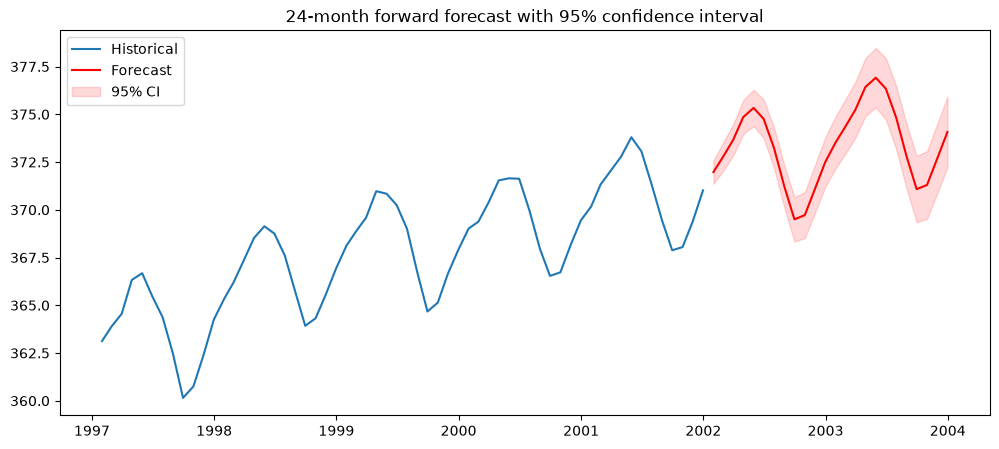

In [4]:
final_model = sm.tsa.statespace.SARIMAX(co2, order=order, seasonal_order=seasonal_order,
                                          enforce_stationarity=False, enforce_invertibility=False)
final_fitted = final_model.fit(disp=False)
future_forecast = final_fitted.get_forecast(steps=24)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int(alpha=0.05)

plt.figure(figsize=(12, 5))
plt.plot(co2[-60:], label="Historical")
plt.plot(future_mean, label="Forecast", color="red")
plt.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1], color="red", alpha=0.15, label="95% CI")
plt.legend()
plt.title("24-month forward forecast with 95% confidence interval")
plt.show()

## Step 6 — Documentation

**Drivers:** Long-term upward trend (visible in decomposition) + strong, 
regular 12-month seasonal cycle.

**Assumptions:** Historical trend and seasonal pattern continue unchanged 
over the forecast horizon; no structural break in the underlying process.

**Validation:** Backtested across 5 rolling windows (not a single split). 
SARIMA(1,1,1)(1,1,1,12) beat the naive seasonal baseline in all 5 of 5 
windows — average MAE 0.510 vs. naive average MAE 1.653, a ~3.2x improvement.

**Risk periods:** Confidence intervals widen further into the 24-month 
forecast horizon — reliability is highest in the first 6-12 months and 
decreases beyond that, consistent with every backtest window showing some 
variation in error (0.268 to 1.068 MAE across windows).